# Predicting Smartphone Addiction

The task is from a [Kaggle competition](https://www.kaggle.com/competitions/playground-series-s6e8). The task itself is a binary classification problem: it is necessary to predict whether there is a dependence on a smartphone addiction on the given features. The features include age, time indicators for various activities, as well as the use of a smartphone by a person for work or study.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Uploading a dataset

In [ ]:
dataset_path = kagglehub.competition_download('playground-series-s6e8')

train = pd.read_csv(dataset_path + "/train.csv")

float64_cols = train.select_dtypes("number").columns

train[float64_cols] = train[float64_cols].astype('float32')

test = pd.read_csv(dataset_path + "/test.csv")

float64_cols_test = test.select_dtypes("number").columns

test[float64_cols_test] = test[float64_cols_test].astype('float32')

In [ ]:
train.head()

In [ ]:
test.head()

In [ ]:
data = pd.concat([train, test.assign(addicted_label=np.nan)])

In [ ]:
data.head()

# Data Analysis

In [ ]:
data.info()

In [ ]:
data.describe()

## NaNs

In [ ]:
data.isnull().sum(axis=0)

In [ ]:
data[data.isnull().all(axis=1)]

In [ ]:
data[data.duplicated()]

There are no completely empty strings or duplicates. However, the data itself contains many gaps.

## Graphs

### Distribution of features

In [ ]:
columns_numbers = test.select_dtypes("number").columns[1:]

figure, axes = plt.subplots(len(columns_numbers), 2, 
                            figsize=(6*2, 5*len(columns_numbers)), 
                            gridspec_kw={'hspace': 0.35})

for i, name_col in enumerate(columns_numbers):

    sns.histplot(train[name_col], kde=True, ax=axes[i, 0])
    sns.histplot(test[name_col], kde=True, ax=axes[i, 1])

    if i == 0:
        axes[i, 0].set_title("Train", fontsize=14)
        axes[i, 1].set_title("Test", fontsize=14)
    axes[i, 0].set_xlabel(name_col, fontsize=12)
    axes[i, 1].set_xlabel(name_col, fontsize=12)

plt.show()

The distribution of numerical data is approximately the same for train and test.

In [ ]:
def generate_pie(x, labels, color, explode):
    plt.pie(
        x=x,
        labels=labels,
        autopct="%.0f%%",
        shadow=True,
        colors=color,
        explode=explode,
        textprops={"size": 12, "weight": "light", "style": "oblique"}
    )

In [ ]:
columns_objects = test.select_dtypes("object").columns

index = 1

plt.figure(figsize=(10, 14))

for name_col_o in columns_objects:
    plt.subplot(4, 2, index)
    plt.suptitle("Compare train and test category features", fontsize=18)
    plt.title(loc="right", label=name_col_o, fontdict={"size": 16, "weight": "light", "style": "oblique"})
    index += 1

    train_column = train[name_col_o].value_counts()
    test_column = test[name_col_o].value_counts()

    if len(train_column.index) == 3:
        explode = [0.05, 0.05, 0.05]
    else:
        explode = [0.1, 0.0]

    generate_pie(
        train_column.values.tolist(),
        train_column.index.tolist(),
        sns.color_palette("hls", len(train_column.index.tolist())),
        explode
    )

    plt.subplot(4, 2, index)
    index += 1

    generate_pie(
        test_column.values.tolist(),
        test_column.index.tolist(),
        sns.color_palette("hls", len(test_column.index.tolist())),
        explode
    )


addicted_label_train = train["addicted_label"].value_counts()
plt.subplot(4, 2, index)
plt.title(loc="right", label="addicted_label", fontdict={"size": 16, "weight": "light", "style": "oblique"})

generate_pie(
        addicted_label_train.values.tolist(),
        addicted_label_train.index.tolist(),
        sns.color_palette("Blues_d", 2),
        [0.0, 0.1]
    )

plt.tight_layout
plt.show()

In [ ]:
plt.figure(figsize=(14, 10))

for i, column in enumerate(list(columns_objects) + ["addicted_label"], 1):
    ax = plt.subplot(2, 2, i)
    df_train = train[[column]].assign(dataset='Train')

    if column == "addicted_label":
        sns.countplot(data=df_train, x=column, hue="addicted_label", palette='hls')
    else:
        df_test = test[[column]].assign(dataset='Test')
        combined_df = pd.concat([df_train, df_test], ignore_index=True)

        sns.countplot(data=combined_df, x=column, hue='dataset', palette='hls')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=12)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

    plt.title(f'Distribution of {column}', fontsize=16)
    plt.xlabel('')
    plt.grid()

plt.tight_layout()
plt.show()

The distribution of categorical data in percentage terms does not differ between train and test. There are minor differences in the numerical ratio.

An imbalance in classes is observed in the target variable.

Since the distribution of numerical and categorical data is approximately the same, we will proceed to work with the overall sample.

In [ ]:
data_columns_numbers = data.select_dtypes("number").columns[1:-1]

cols = 3
rows = 3

figure_data, axes_data = plt.subplots(rows, cols, 
                            figsize=(6*cols, 6*rows), 
                            gridspec_kw={'hspace': 0.15})

for ind, name_col_data in enumerate(data_columns_numbers):

    row = ind // cols
    col = ind % cols

    sns.boxenplot(data=data[name_col_data], orient="h", ax=axes_data[row, col], color="mediumseagreen")

    axes_data[row, col].set_title(name_col_data, fontsize=14)
    axes_data[row, col].set_xlabel("")

plt.show()

There are almost no outliers, and isolated deviations are quite real.

### Relationship

In [ ]:
def generate_relationship_graphs(name_columns, n_rows):
    df = train
    _, axes_d = plt.subplots(n_rows * 2, cols, 
                                figsize=(7*cols, 8*n_rows), 
                                gridspec_kw={'hspace': 0.2, 'wspace': 0.1})

    plt.suptitle("Ralitonship Features and Addicted Label", fontsize=18)

    for ind_r, name_col_r in enumerate(name_columns):

        bins = pd.qcut(df[name_col_r], q=10, duplicates="drop")

        row_r = ind_r // cols
        col_r = ind_r % cols

        sns.kdeplot(
            data=train, 
            x=name_col_r, 
            hue="addicted_label", 
            common_norm=False, 
            fill=True, 
            alpha=0.4,
            ax=axes_d[row_r*2, col_r]
        )
        sns.move_legend(
            axes_d[row_r * 2, col_r], loc="upper left"
        )

        df.groupby(bins, observed=True)["addicted_label"].mean().plot(
            kind="line", 
            marker="o", 
            color="green",
            ax=axes_d[1+row_r*2, col_r]
        )

        axes_d[row_r*2, col_r].set_xlabel("")
        axes_d[row_r*2, col_r].set_ylabel("")
        axes_d[row_r*2, col_r].set_title(name_col_r, fontsize=16)
        axes_d[1+row_r*2, col_r].set_xlabel("")


    plt.tight_layout
    plt.show()

In [ ]:
cols_relationship_num = train.select_dtypes("number").columns[1:-1]

In [ ]:
generate_relationship_graphs(cols_relationship_num[:6], 2)

In [ ]:
generate_relationship_graphs(cols_relationship_num[6:], 1)

In [ ]:
plt.figure(figsize=(14, 5))
plt.title("Addiction Rate by Categorical Features", fontsize=18)
for ind_r_o, name_col_r in enumerate(columns_objects):
    plt.subplot(1, 3, ind_r_o+1)
    sns.barplot(
        data=train,
        hue=name_col_r,
        x=name_col_r, 
        y="addicted_label",
        palette='Blues_d'
    )

plt.show()

The graphs show that the following factors have the greatest impact on smartphone addiction: daily_screen_time_hours, social_media_hours, gaming_hours, work_study_hours, and weekend_screen_time. The categorical features, taken individually, do not create any significant differences among the classes. The remaining features are of secondary importance.

### Correlation

In [ ]:
df = data.drop(["id"], axis=1)

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Multicolleniarity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
df_numeric = train.select_dtypes("number").drop(["id"], axis=1)

In [ ]:
df_vif = sm.add_constant(df_numeric.fillna(df_numeric.median(numeric_only=True)))
vif_df = pd.DataFrame()
vif_df["feature"] = df_vif.columns
vif_df["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

In [ ]:
vif_df.sort_values("VIF", ascending=False)

The correlation is small, and only in logical places; there is no multicollinearity, and nothing needs to be corrected.

# Feature Engineering

According to the graphs above, no anomalous values are observed. The only changes needed are to fill in the gaps separately for the train and test datasets.
As for the changes in the features, the id column will need to be removed to prevent data leakage. Additionally, 3 features should be added to better understand the data.

In [ ]:
df['social_ratio'] = df['social_media_hours'] / (df['daily_screen_time_hours'] + 1e-5)
df['gaming_ratio'] = df['gaming_hours'] / (df['daily_screen_time_hours'] + 1e-5)
df['work_ratio'] = df['work_study_hours'] / (df['daily_screen_time_hours'] + 1e-5)

I added ratio indicators showing what proportion of screen time each type of activity occupies.

# Preprocessing data

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

In [ ]:
train_data = df[df["addicted_label"].notna()]
test_data = df[df["addicted_label"].isnull()]

train_sub_data, val_data = train_test_split(train_data, 
                            test_size=0.2, 
                            random_state=True, 
                            shuffle=True,
                            stratify=train_data["addicted_label"]
                           )

train_data_wt_y = train_sub_data.drop(["addicted_label"], axis=1)
y_train = train_sub_data["addicted_label"]

val_data_wt_y = val_data.drop(["addicted_label"], axis=1)
y_val = val_data["addicted_label"]

test_data_wt_y = test_data.drop(["addicted_label"], axis=1)
y_test = test_data["addicted_label"]

## Train Pipeline

In [ ]:
def generate_preprocessor(data):

    numeric = data.select_dtypes("number").columns

    category = data.select_dtypes("object").drop(["academic_work_impact"], axis=1).columns

    bool = ["academic_work_impact"]

    transformer_nums = Pipeline(steps=[
        #("imputer", KNNImputer(n_neighbors=5))
        ("imputer", SimpleImputer(strategy="median")),
        # ("imputer", IterativeImputer(estimator=CatBoostRegressor(), max_iter=10, random_state=42))
        ("scaler", StandardScaler())
    ])

    transformer_cat = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first"))
    ])

    transformer_bool = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", categories=[["No", "Yes"]], sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("number", transformer_nums, numeric),
            ("category", transformer_cat, category),
            ("bool", transformer_bool, bool)
        ],
        n_jobs=-1
    )

    return preprocessor

As an imputer for numerical features, you can try KNNimputer and IterativeImputer, but they take a very long time to run on this dataset, and the latter turned out to be worse than the standard SimpleImputer.

In [ ]:
preprocessor = generate_preprocessor(train_data_wt_y)
X_train_prep = preprocessor.fit_transform(train_sub_data, y_train)

## Validation Pipeline

In [ ]:
X_val_prep = preprocessor.transform(val_data_wt_y)

## Test Pipeline

In [ ]:
X_test_prep = preprocessor.transform(test_data_wt_y)

# Models

The models used:
 - LogisticRegression
 - RandomForestClassifier
 - CatBoostClassifier
 - FullyConnectedNN

To launch mlflow:

mlflow ui --backend-store-uri sqlite:///mlflow/data/mlflow.db

In [ ]:
from tools.mlflow_train import train_model, train_nn_model
from tools.tune_params import tune_model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

## LogisticRegression

In [ ]:
params_lr = {
    "C": [0.5, 0.75, 1.0],
    "fit_intercept": [True, False],
    "random_state": [42],
    "max_iter": [1000]
}

In [ ]:
best_param_lr = tune_model(LogisticRegression, params_lr, X_train_prep, y_train, X_val_prep, y_val, n_trials=20)

In [ ]:
best_param_lr

In [ ]:
model_lr = LogisticRegression(C=0.75, fit_intercept=True, max_iter=1000, random_state=42)

In [ ]:
train_model(model=model_lr, model_name="LogisticRegression", X_train=X_train_prep, y_train=y_train.to_numpy(), X_val=X_val_prep, y_val=y_val.to_numpy())

Metrics from logging in mlflow:
 - val/accuracy = 0.843
 - val/precision = 0.873
 - val/recall - 0.912
 - val/f1_weighted = 0.841
 - val/roc_auc = 0.918

**Learning Curve LogisticRegression**

**Validation F1 score**
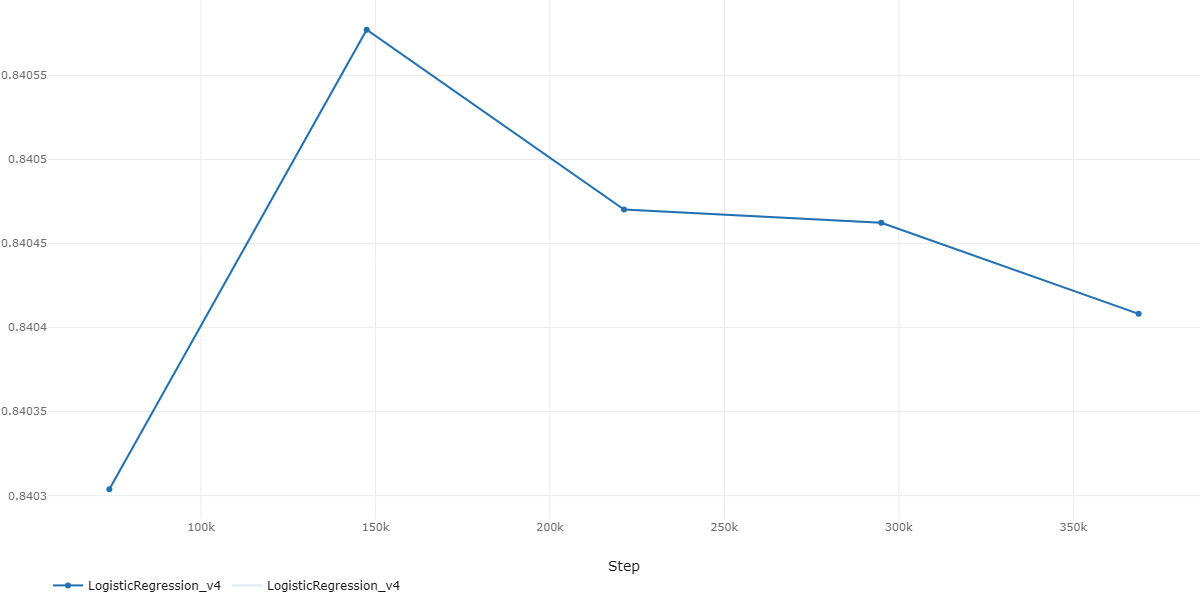

In the construction of the Learning Curve, Data Leakage is observed due to cross‑validation, as the gaps are filled with the median and mode. However, data leakage occurs only when constructing the graph; the model itself does not have this problem, so I leave it as is.

## RandomForestClassifier

In [ ]:
params_rf = {
    "n_estimators": [50, 100, 200, 300],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 40],
    "min_samples_leaf": [1, 10, 20, 40],
    "max_features": ["sqrt", "log2"],
    "n_jobs": [-1],
    "random_state": [42]
}

In [ ]:
best_param_rf = tune_model(RandomForestClassifier, params_rf, X_train_prep, y_train, X_val_prep, y_val, n_trials=20)

In [ ]:
best_param_rf

In [ ]:
model_rf = RandomForestClassifier(n_estimators=300, criterion="entropy", max_depth=None, min_samples_split=20, min_samples_leaf=10, max_features="log2", random_state=42)

In [ ]:
train_model(model=model_rf, model_name="RandomForestClassifier", X_train=X_train_prep, y_train=y_train.to_numpy(), X_val=X_val_prep, y_val=y_val.to_numpy())

Metrics from logging in mlflow:
- val/accuracy = 0.872
- val/precision = 0.897
- val/recall = 0.926
- val/f1_weighted = 0.87
- val/roc_auc = 0.943

**Learning Curve RandomForestClassifier**

**Validation F1 score**
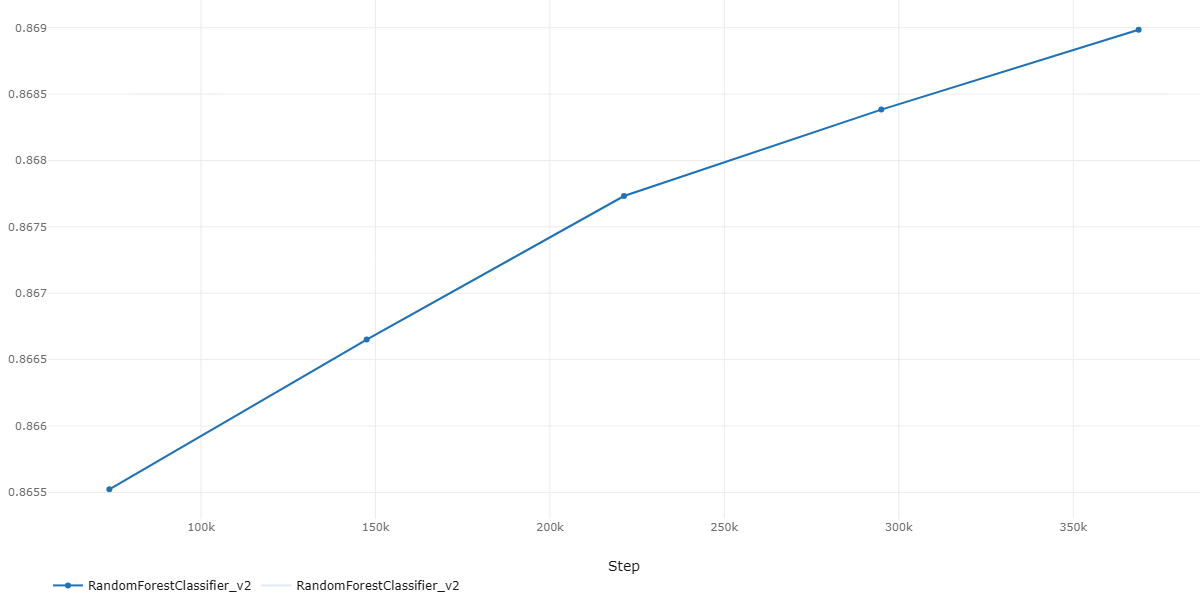

## CatBoostClassifier

In [ ]:
params_cb = {
    "iterations": [300, 500, 1000, 1500],
    "learning_rate": [0.05, 0.1, 0.3, 0.5],
    "depth": [6, 10, 13, 16],
    "loss_function": ["Logloss"],
    "l2_leaf_reg": [1.0, 3.0, 7.0],
    "early_stopping_rounds": [50],
    "use_best_model": [True, False],
    "verbose": [False],
    "random_seed": [42],
    "min_data_in_leaf": [20, 50, 75]
}

In [ ]:
best_param_cb = tune_model(CatBoostClassifier, params_cb, X_train_prep, y_train, X_val_prep, y_val, n_trials=20)

In [ ]:
best_param_cb

In [ ]:
model_cb = CatBoostClassifier(iterations=1500, learning_rate=0.1, depth=10, loss_function='Logloss', l2_leaf_reg=7.0, early_stopping_rounds=50, use_best_model=False, verbose=False, random_seed=42, min_data_in_leaf=50)

In [ ]:
train_model(model=model_cb, model_name="CatBoostClassifier", X_train=X_train_prep, y_train=y_train.astype(int).to_numpy(), X_val=X_val_prep, y_val=y_val.astype(int).to_numpy())

Metrics from logging in mlflow:
- val/accuracy = 0.9
- val/precision = 0.924
- val/recall = 0.937
- val/f1_weighted = 0.9
- val/roc_auc = 0.962

**Learning Curve CatBoostClassifier**

**Validation F1 score**
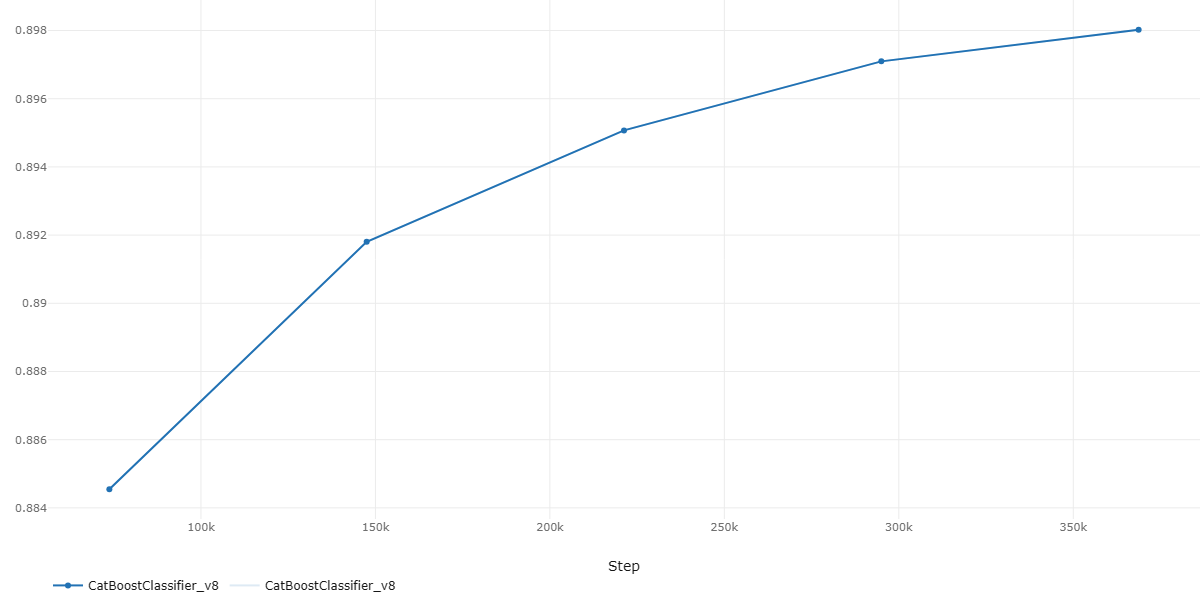

### CatBoost v2

Here, I’m providing the model with unprocessed, raw data, since the CatBoost model has a complex data processing structure, which can yield better results.

In [ ]:
model_cb_v2 = CatBoostClassifier(iterations=1500, learning_rate=0.1, depth=10, loss_function='Logloss', l2_leaf_reg=7.0, early_stopping_rounds=50, use_best_model=False, verbose=False, random_seed=42, min_data_in_leaf=50, cat_features=columns_objects.tolist())

In [ ]:
train_data_copy = train_data_wt_y.copy()
val_data_copy = val_data_wt_y.copy()

cat_cols = columns_objects.tolist()
train_data_copy[cat_cols] = train_data_copy[cat_cols].fillna("missing").astype(str)
val_data_copy[cat_cols] = val_data_copy[cat_cols].fillna("missing").astype(str)

train_data_copy = train_data_copy.reset_index(drop=True)
val_data_copy = val_data_copy.reset_index(drop=True)

In [ ]:
train_model(model=model_cb_v2, model_name="CatBoostClassifier", X_train=train_data_copy, y_train=y_train.to_numpy(), X_val=val_data_copy, y_val=y_val.to_numpy(), lc_flag=False)

Metrics from logging in mlflow:
- val/accuracy = 0.901
- val/precision = 0.924
- val/recall = 0.936
- val/f1_weighted = 0.9
- val/roc_auc = 0.963

## Fully Connected NN

In [ ]:
from torch.utils.data import DataLoader
from tools.fully_connected_nn import FullyConnectedNN, CustomDataset

In [ ]:
model = FullyConnectedNN()

In [ ]:
train_data_pt = CustomDataset(X=X_train_prep, y=y_train)
val_data_pt = CustomDataset(X=X_val_prep, y=y_val)

In [ ]:
train_loader = DataLoader(dataset=train_data_pt, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_data_pt, batch_size=32, shuffle=False)

In [ ]:
metrics, f1_scores, roc_auc = train_nn_model(model_name="FullyConnectedNN", model=model, epochs=15, train_loader=train_loader, val_loader=val_loader, learning_rate=0.001)

In [ ]:
metrics

Metrics from logging in mlflow:
- val/accuracy = 0.865
- val/precision = 0.885
- val/recall = 0.93
- val/f1_weighted = 0.862
- val/roc_auc = 0.938

**Learning Curve FullyConnectedNN**

**Validation Loss**
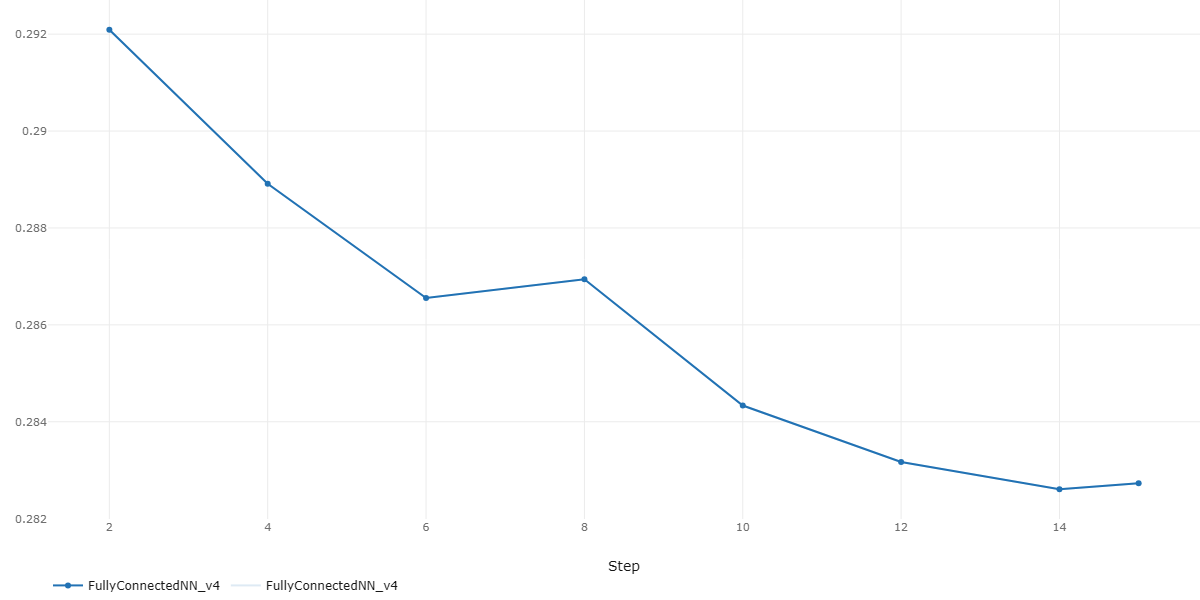

# Testing model

Based on the results, the best models turned out to be CatBoostClassifier and CatBoostClassifier_v2 (without data preprocessing), and I will use them to run the model on the test dataset.

In [ ]:
import mlflow

In [ ]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [ ]:
model_mlflow = mlflow.catboost.load_model("models:/CatBoost/latest")

In [ ]:
test_data_copy = test_data.copy()

test_data_copy[cat_cols] = test_data_copy[cat_cols].fillna("missing").astype(str)

test_data_copy = test_data_copy.reset_index(drop=True)

In [ ]:
test_preds_proba = model_mlflow.predict_proba(test_data_copy)[:, 1]

submission = pd.DataFrame({
    'id': test['id'],
    'addicted_label': test_preds_proba
})

submission.to_csv('submission.csv', index=False)

## Attempt to improve the result using Weight Blending

In [ ]:
import scipy
from scipy.stats import rankdata

In [ ]:
model_catboost_v2_mlflow = mlflow.catboost.load_model("models:/CatBoost/latest")
model_catboost_mlflow = mlflow.catboost.load_model("models:/CatBoost/3")
model_logreg_mlflow = mlflow.sklearn.load_model("models:/LogisticRegression/latest")
model_randforest_mlflow = mlflow.sklearn.load_model("models:/RandomForest/latest")
model_fcnn_mlflow = mlflow.pytorch.load_model("models:/FullyConnected/latest")

In [ ]:
p_cb = model_catboost_mlflow.predict_proba(X_test_prep)[:, 1]
p_cb_v2 = model_catboost_v2_mlflow.predict_proba(test_data_copy)[:, 1]

p_lr = model_logreg_mlflow.predict_proba(X_test_prep)[:, 1]
p_rf = model_randforest_mlflow.predict_proba(X_test_prep)[:, 1]

p_fcnn = model_fcnn_mlflow.predict(X_test_prep)

In [ ]:
r_cb = rankdata(p_cb) / len(p_cb)
r_cb_v2 = rankdata(p_cb_v2) / len(p_cb_v2)
r_rf = rankdata(p_rf) / len(p_rf)
r_fcnn = rankdata(p_fcnn) / len(p_fcnn)
r_lr = rankdata(p_lr) / len(p_lr)

# final_rank_preds = 0.3 * r_cb + 0.3 * r_cb_v2 + 0.15 * r_fcnn + 0.15 * r_rf + 0.1 * r_lr
final_rank_preds = 0.45 * r_cb + 0.55 * r_cb_v2
# final_rank_preds = 0.45 * p_cb + 0.55 * p_cb_v2

Using rankdata, we convert from probabilities to relative order so that different probabilistic spaces of models do not interfere with each other.

In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'addicted_label': final_rank_preds
})

submission.to_csv('submission_s.csv', index=False)

The final ROC-AUC result is 0,96449.

# Conclusion

In the end, the results showed that the CatBoost model trained on raw data achieved the best result. The CatBoost model trained on preprocessed data performed slightly worse, but not significantly, and Weighted Blending, among all my models, did not show the good result I expected from it; it turned out to be worse by about 1–2% compared to the CatBoost model. Blending two CatBoost models trained using different approaches yielded the absolute best result from my experiments.

Overall, in my work I focused more on using the ML stack: ONNX, MLflow, Optuna, CatBoost, sklearn. The dataset wasn’t complex; its main problem was the gaps of data. I added 3 new features to better understand the data.

I could have tried experimenting with features or models to get a few more thousandths in the result, but that wasn’t my goal for this work.